# MCMC simulation for Bayesian inference in a stochastic volatility model

This notebook provides an appendix-style computational illustration of Markov chain Monte Carlo (MCMC) inference for the stochastic volatility (SV) model used in the thesis. The aim is to show how Bayesian simulation can recover an unobserved volatility path from observed returns.

The notebook deliberately keeps the model parameters fixed at their simulation values. This isolates the latent-state inference problem, which is the core difficulty in SV models: the econometrician observes returns $r_t$, while the log-volatility states $h_t$ are hidden.

In [1]:
from pathlib import Path
import os
import tempfile
import time

# Keep Matplotlib cache outside the repository and avoid local permission warnings.
MPLCONFIGDIR = Path(tempfile.gettempdir()) / "matplotlib-cache"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

import numpy as np
import matplotlib.pyplot as plt

FIGURE_DIR = Path("figures/mcmc_simulation")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})


def save_figure(fig, filename):
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"saved: {path}")
    return path

## 1. Simulated data-generating process

The return process is the same basic SV model used in the simulation appendix:

$$
h_t = \mu + \phi(h_{t-1} - \mu) + \eta_t, \qquad \eta_t \sim N(0, \sigma_\eta^2),
$$

$$
r_t = \exp(h_t/2)\varepsilon_t, \qquad \varepsilon_t \sim N(0,1).
$$

The values $\mu=-0.5$, $\phi=0.98$, and $\sigma_\eta=0.15$ generate persistent volatility clustering. A moderate sample size is used so the MCMC runs quickly while still showing the latent-state structure.

In [2]:
def simulate_sv(T=250, mu=-0.5, phi=0.98, sigma_eta=0.15, seed=123):
    """Simulate a stochastic volatility return series."""
    if not -1 < phi < 1:
        raise ValueError("Stationary initialization requires |phi| < 1.")

    rng = np.random.default_rng(seed)
    h = np.empty(T)
    h[0] = rng.normal(mu, sigma_eta / np.sqrt(1 - phi**2))

    for t in range(1, T):
        h[t] = mu + phi * (h[t - 1] - mu) + rng.normal(0, sigma_eta)

    sigma = np.exp(h / 2)
    r = sigma * rng.normal(0, 1, T)
    return {"time": np.arange(1, T + 1), "h": h, "sigma": sigma, "r": r}


PARAMS = {"T": 250, "mu": -0.5, "phi": 0.98, "sigma_eta": 0.15, "seed": 2026}
data = simulate_sv(**PARAMS)

time_index = data["time"]
r = data["r"]
true_h = data["h"]
true_sigma = data["sigma"]

PARAMS

{'T': 250, 'mu': -0.5, 'phi': 0.98, 'sigma_eta': 0.15, 'seed': 2026}

saved: figures/mcmc_simulation/mcmc_simulated_data.png


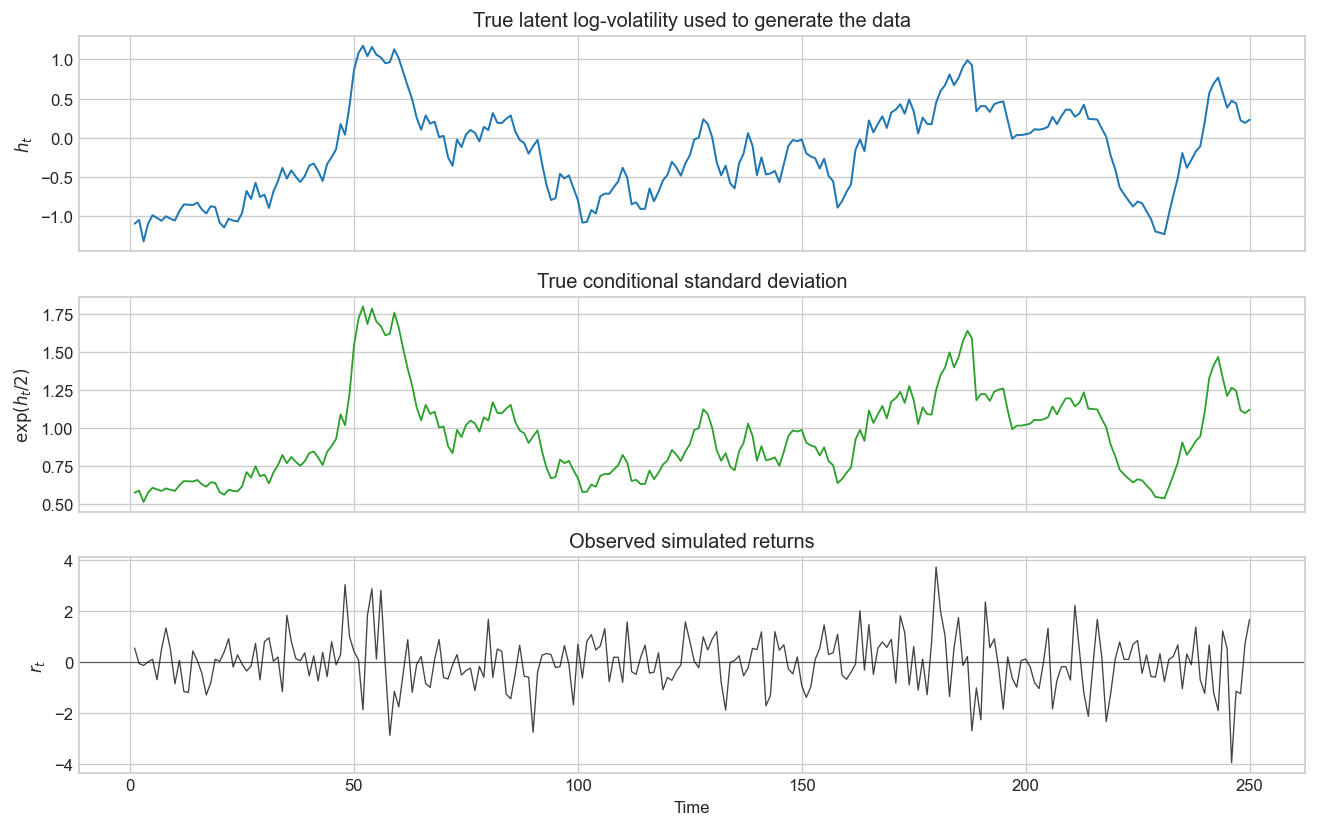

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)

axes[0].plot(time_index, true_h, color="#1f77b4", linewidth=1.2)
axes[0].set_title("True latent log-volatility used to generate the data")
axes[0].set_ylabel(r"$h_t$")

axes[1].plot(time_index, true_sigma, color="#2ca02c", linewidth=1.1)
axes[1].set_title("True conditional standard deviation")
axes[1].set_ylabel(r"$\exp(h_t/2)$")

axes[2].plot(time_index, r, color="#444444", linewidth=0.8)
axes[2].axhline(0, color="#111111", linewidth=0.7, alpha=0.6)
axes[2].set_title("Observed simulated returns")
axes[2].set_xlabel("Time")
axes[2].set_ylabel(r"$r_t$")

fig.tight_layout()
save_figure(fig, "mcmc_simulated_data.png")
plt.show()

## 2. Posterior target and MCMC design

Conditional on known parameters, the posterior target is

$$
p(h_{1:T} \mid r_{1:T}, \mu, \phi, \sigma_\eta) \propto
\prod_{t=1}^T p(r_t \mid h_t) \; p(h_1) \prod_{t=2}^T p(h_t \mid h_{t-1}).
$$

The sampler below is a random-scan Metropolis-within-Gibbs algorithm. At each MCMC iteration it proposes a local move for every latent state $h_t$ and accepts or rejects it using the one-dimensional full conditional kernel. This is slower than modern specialized SV samplers, but it is transparent and useful for illustrating why MCMC is needed.

In [4]:
def log_observation_density(y, h_value):
    """Log p(y_t | h_t), ignoring constants independent of h_t."""
    return -0.5 * (h_value + y**2 * np.exp(-h_value))


def log_normal_kernel(x, mean, sd):
    return -0.5 * ((x - mean) / sd) ** 2


def log_full_conditional(t, h_value, h_path, returns, mu, phi, sigma_eta):
    """Log full conditional kernel for one h_t value."""
    T = len(h_path)
    out = log_observation_density(returns[t], h_value)

    if t == 0:
        stationary_sd = sigma_eta / np.sqrt(1 - phi**2)
        out += log_normal_kernel(h_value, mu, stationary_sd)
    else:
        mean_t = mu + phi * (h_path[t - 1] - mu)
        out += log_normal_kernel(h_value, mean_t, sigma_eta)

    if t < T - 1:
        mean_next = mu + phi * (h_value - mu)
        out += log_normal_kernel(h_path[t + 1], mean_next, sigma_eta)

    return out


def log_posterior_h(h_path, returns, mu, phi, sigma_eta):
    """Joint log posterior kernel for h_{1:T}, up to an additive constant."""
    stationary_sd = sigma_eta / np.sqrt(1 - phi**2)
    out = log_normal_kernel(h_path[0], mu, stationary_sd)
    out += np.sum(log_observation_density(returns, h_path))

    transition_mean = mu + phi * (h_path[:-1] - mu)
    out += np.sum(log_normal_kernel(h_path[1:], transition_mean, sigma_eta))
    return out


def moving_average(x, window=25):
    weights = np.ones(window) / window
    return np.convolve(x, weights, mode="same")


def initialize_h_from_returns(returns, mu=-0.5, seed=1):
    """Create an observed-data initialization without using the true h_t path."""
    rng = np.random.default_rng(seed)
    log_squared = np.log(returns**2 + 1e-4)
    smoothed = moving_average(log_squared, window=25)
    centered = smoothed - smoothed.mean() + mu
    return centered + rng.normal(0, 0.2, size=len(returns))

In [5]:
def run_mcmc_chain(
    returns,
    mu,
    phi,
    sigma_eta,
    n_iter=2500,
    burn_in=1000,
    proposal_sd=0.35,
    seed=1,
):
    rng = np.random.default_rng(seed)
    T = len(returns)
    h_path = initialize_h_from_returns(returns, mu=mu, seed=seed)

    kept = n_iter - burn_in
    draws = np.empty((kept, T))
    log_posterior_trace = np.empty(kept)
    accepted = np.zeros(T, dtype=int)

    keep_idx = 0
    for iteration in range(n_iter):
        for t in rng.permutation(T):
            current = h_path[t]
            proposal = current + rng.normal(0, proposal_sd)

            log_current = log_full_conditional(t, current, h_path, returns, mu, phi, sigma_eta)
            log_proposal = log_full_conditional(t, proposal, h_path, returns, mu, phi, sigma_eta)

            if np.log(rng.random()) < log_proposal - log_current:
                h_path[t] = proposal
                accepted[t] += 1

        if iteration >= burn_in:
            draws[keep_idx] = h_path
            log_posterior_trace[keep_idx] = log_posterior_h(h_path, returns, mu, phi, sigma_eta)
            keep_idx += 1

    return {
        "draws": draws,
        "log_posterior": log_posterior_trace,
        "acceptance_rate": accepted / n_iter,
    }


N_CHAINS = 4
N_ITER = 2500
BURN_IN = 1000
PROPOSAL_SD = 0.35

start = time.time()
chains = []
for chain_id in range(N_CHAINS):
    chain = run_mcmc_chain(
        r,
        mu=PARAMS["mu"],
        phi=PARAMS["phi"],
        sigma_eta=PARAMS["sigma_eta"],
        n_iter=N_ITER,
        burn_in=BURN_IN,
        proposal_sd=PROPOSAL_SD,
        seed=500 + chain_id,
    )
    chains.append(chain)

elapsed = time.time() - start
draws_by_chain = np.stack([chain["draws"] for chain in chains])
log_post_by_chain = np.stack([chain["log_posterior"] for chain in chains])
acceptance_by_chain = np.stack([chain["acceptance_rate"] for chain in chains])

print(f"Completed {N_CHAINS} chains in {elapsed:.1f} seconds")
print(f"Draws kept per chain: {N_ITER - BURN_IN}")
print(f"Mean acceptance rate: {acceptance_by_chain.mean():.3f}")
print(f"Acceptance rate range: {acceptance_by_chain.min():.3f} to {acceptance_by_chain.max():.3f}")

Completed 4 chains in 13.4 seconds
Draws kept per chain: 1500
Mean acceptance rate: 0.350
Acceptance rate range: 0.316 to 0.463


## 3. Posterior recovery of the latent volatility path

After burn-in, the chains provide draws from the posterior distribution of $h_{1:T}$. The next figures compare the posterior mean and 90% credible interval with the true simulated log-volatility path. In real financial data this true path is unavailable, but in a simulation it provides a direct check of the Bayesian recovery mechanism.

Posterior recovery diagnostics
--------------------------------------
RMSE for h_t posterior mean:          0.3668
90% interval coverage for h_t:        0.8400
RMSE for exp(h_t/2) posterior mean:   0.1756
saved: figures/mcmc_simulation/mcmc_posterior_log_volatility.png


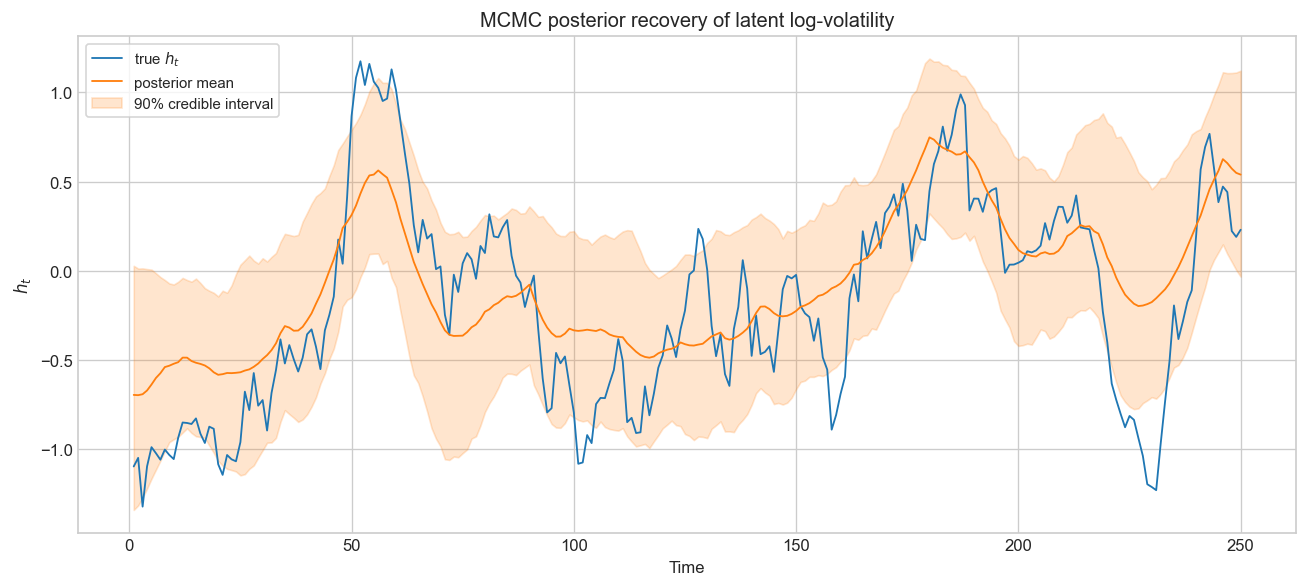

saved: figures/mcmc_simulation/mcmc_posterior_conditional_sd.png


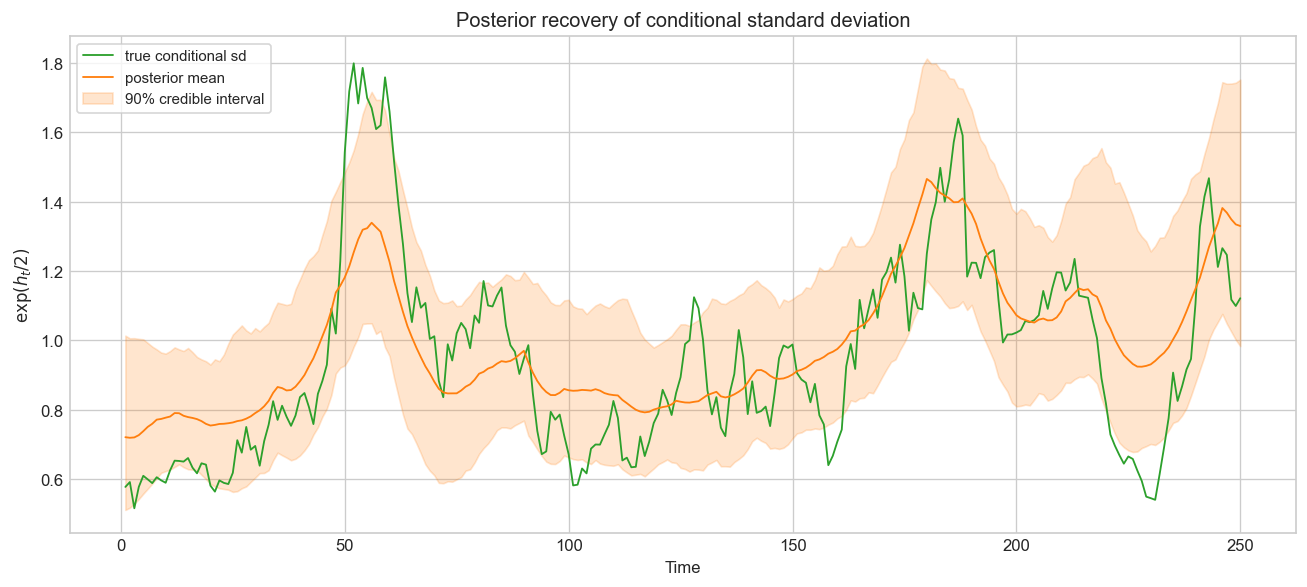

In [6]:
posterior_draws = draws_by_chain.reshape(-1, PARAMS["T"])
posterior_mean_h = posterior_draws.mean(axis=0)
posterior_q05_h, posterior_q95_h = np.quantile(posterior_draws, [0.05, 0.95], axis=0)

posterior_sigma_draws = np.exp(posterior_draws / 2)
posterior_mean_sigma = posterior_sigma_draws.mean(axis=0)
posterior_q05_sigma, posterior_q95_sigma = np.quantile(posterior_sigma_draws, [0.05, 0.95], axis=0)

rmse_h = np.sqrt(np.mean((posterior_mean_h - true_h) ** 2))
coverage_h = np.mean((true_h >= posterior_q05_h) & (true_h <= posterior_q95_h))
rmse_sigma = np.sqrt(np.mean((posterior_mean_sigma - true_sigma) ** 2))

print("Posterior recovery diagnostics")
print("-" * 38)
print(f"RMSE for h_t posterior mean:        {rmse_h:>8.4f}")
print(f"90% interval coverage for h_t:      {coverage_h:>8.4f}")
print(f"RMSE for exp(h_t/2) posterior mean: {rmse_sigma:>8.4f}")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(time_index, true_h, color="#1f77b4", linewidth=1.1, label="true $h_t$")
ax.plot(time_index, posterior_mean_h, color="#ff7f0e", linewidth=1.1, label="posterior mean")
ax.fill_between(time_index, posterior_q05_h, posterior_q95_h, color="#ff7f0e", alpha=0.20, label="90% credible interval")
ax.set_title("MCMC posterior recovery of latent log-volatility")
ax.set_xlabel("Time")
ax.set_ylabel(r"$h_t$")
ax.legend(frameon=True)
fig.tight_layout()
save_figure(fig, "mcmc_posterior_log_volatility.png")
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(time_index, true_sigma, color="#2ca02c", linewidth=1.1, label="true conditional sd")
ax.plot(time_index, posterior_mean_sigma, color="#ff7f0e", linewidth=1.1, label="posterior mean")
ax.fill_between(time_index, posterior_q05_sigma, posterior_q95_sigma, color="#ff7f0e", alpha=0.20, label="90% credible interval")
ax.set_title("Posterior recovery of conditional standard deviation")
ax.set_xlabel("Time")
ax.set_ylabel(r"$\exp(h_t/2)$")
ax.legend(frameon=True)
fig.tight_layout()
save_figure(fig, "mcmc_posterior_conditional_sd.png")
plt.show()

The posterior mean tracks persistent changes in volatility, while the interval remains wide enough to reflect the fact that volatility is only indirectly observed through noisy returns.

## 4. MCMC diagnostics

The next diagnostics are standard checks for an MCMC-based Bayesian analysis: trace plots, autocorrelation plots, acceptance rates, and a simple potential scale reduction factor $\hat{R}$ across the four chains.

Selected latent-state diagnostics
----------------------------------------------
   state      R-hat        ESS    post mean     true h
    t=40      1.045       45.8       -0.279     -0.357
    t=90      1.087       54.9       -0.079     -0.108
   t=140      1.024       49.8       -0.284     -0.478
   t=190      1.015       67.7        0.607      0.404
   t=230      1.254       44.2       -0.176     -1.213
saved: figures/mcmc_simulation/mcmc_trace_selected_states.png


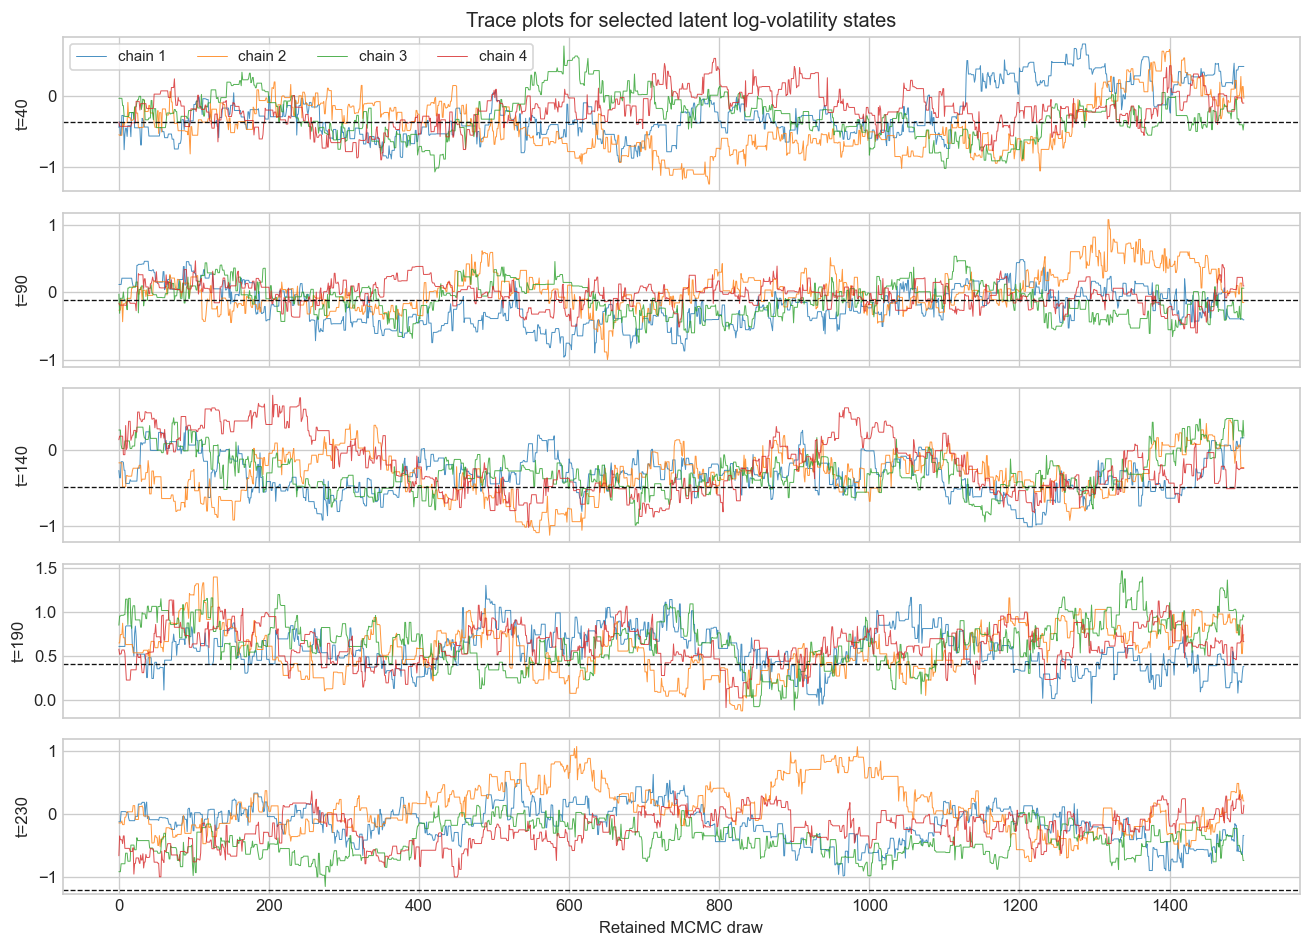

saved: figures/mcmc_simulation/mcmc_acf_selected_states.png


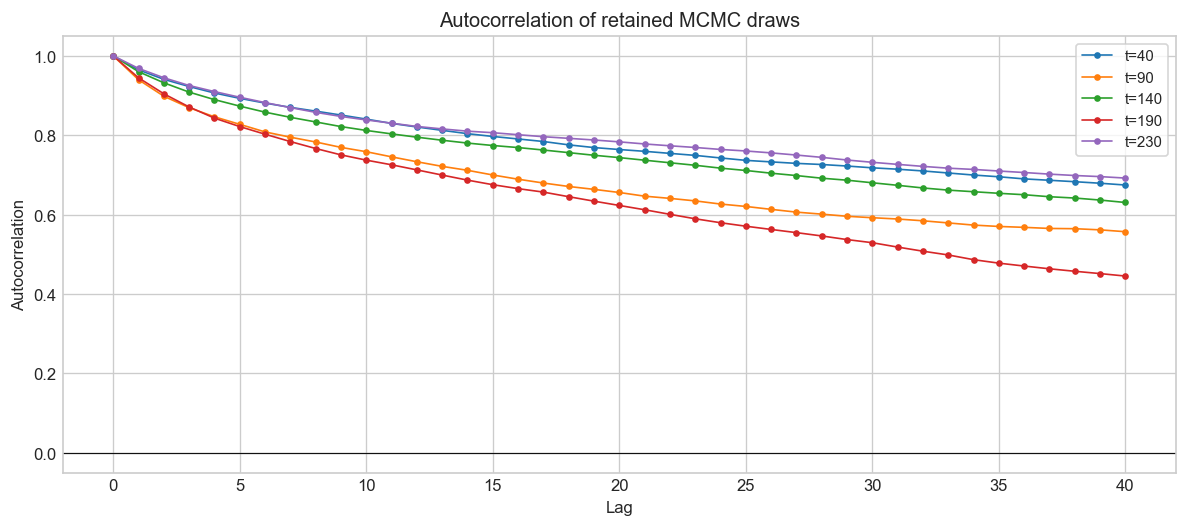

saved: figures/mcmc_simulation/mcmc_logposterior_acceptance.png


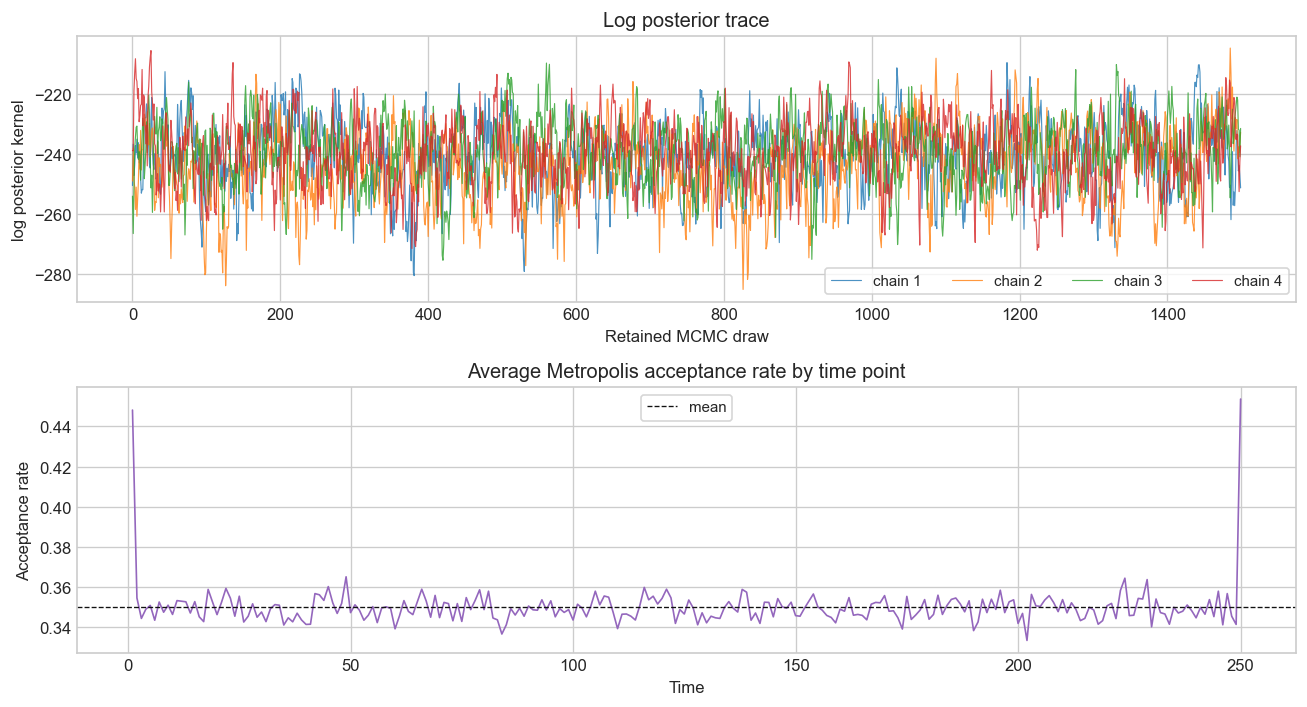

In [7]:
def autocorrelation(x, max_lag=60):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    denom = np.dot(x, x)
    out = np.empty(max_lag + 1)
    out[0] = 1.0
    for lag in range(1, max_lag + 1):
        out[lag] = np.dot(x[:-lag], x[lag:]) / denom
    return out


def effective_sample_size(x, max_lag=100):
    acf = autocorrelation(x, max_lag=max_lag)
    tau = 1.0
    for lag in range(1, max_lag, 2):
        pair_sum = acf[lag] + acf[lag + 1]
        if pair_sum <= 0:
            break
        tau += 2.0 * pair_sum
    return len(x) / tau


def rhat(chains_array):
    """Compute basic R-hat for chains shaped (chains, draws, variables)."""
    m, n = chains_array.shape[:2]
    chain_means = chains_array.mean(axis=1)
    chain_vars = chains_array.var(axis=1, ddof=1)
    W = chain_vars.mean(axis=0)
    B = n * chain_means.var(axis=0, ddof=1)
    var_hat = ((n - 1) / n) * W + (B / n)
    return np.sqrt(var_hat / W)


selected_times = np.array([40, 90, 140, 190, 230])
selected_idx = selected_times - 1
selected_labels = [f"t={t}" for t in selected_times]

rhat_h = rhat(draws_by_chain)
rhat_selected = rhat_h[selected_idx]
ess_selected = [effective_sample_size(posterior_draws[:, idx]) for idx in selected_idx]

print("Selected latent-state diagnostics")
print("-" * 46)
print(f"{'state':>8} {'R-hat':>10} {'ESS':>10} {'post mean':>12} {'true h':>10}")
for label, idx, rh, ess in zip(selected_labels, selected_idx, rhat_selected, ess_selected):
    print(f"{label:>8} {rh:>10.3f} {ess:>10.1f} {posterior_mean_h[idx]:>12.3f} {true_h[idx]:>10.3f}")

fig, axes = plt.subplots(len(selected_idx), 1, figsize=(11, 8), sharex=True)
for ax, idx, label in zip(axes, selected_idx, selected_labels):
    for chain_id in range(N_CHAINS):
        ax.plot(draws_by_chain[chain_id, :, idx], linewidth=0.6, alpha=0.8, label=f"chain {chain_id + 1}" if idx == selected_idx[0] else None)
    ax.axhline(true_h[idx], color="#111111", linestyle="--", linewidth=0.8)
    ax.set_ylabel(label)
axes[0].set_title("Trace plots for selected latent log-volatility states")
axes[-1].set_xlabel("Retained MCMC draw")
axes[0].legend(frameon=True, ncol=4)
fig.tight_layout()
save_figure(fig, "mcmc_trace_selected_states.png")
plt.show()

fig, ax = plt.subplots(figsize=(10, 4.5))
lags = np.arange(41)
for idx, label in zip(selected_idx, selected_labels):
    acf = autocorrelation(posterior_draws[:, idx], max_lag=40)
    ax.plot(lags, acf, marker="o", markersize=3, linewidth=1.0, label=label)
ax.axhline(0, color="#111111", linewidth=0.7)
ax.set_title("Autocorrelation of retained MCMC draws")
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")
ax.legend(frameon=True)
fig.tight_layout()
save_figure(fig, "mcmc_acf_selected_states.png")
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=False)
for chain_id in range(N_CHAINS):
    axes[0].plot(log_post_by_chain[chain_id], linewidth=0.7, alpha=0.8, label=f"chain {chain_id + 1}")
axes[0].set_title("Log posterior trace")
axes[0].set_xlabel("Retained MCMC draw")
axes[0].set_ylabel("log posterior kernel")
axes[0].legend(frameon=True, ncol=4)

mean_acceptance = acceptance_by_chain.mean(axis=0)
axes[1].plot(time_index, mean_acceptance, color="#9467bd", linewidth=1.0)
axes[1].axhline(mean_acceptance.mean(), color="#111111", linestyle="--", linewidth=0.8, label="mean")
axes[1].set_title("Average Metropolis acceptance rate by time point")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Acceptance rate")
axes[1].legend(frameon=True)

fig.tight_layout()
save_figure(fig, "mcmc_logposterior_acceptance.png")
plt.show()

## 5. Posterior distributions for individual volatility states

The posterior distribution of a single $h_t$ can be broad and asymmetric in finite samples. The histograms below show the marginal posterior at selected dates. The vertical line marks the true simulated state, which is used here only for validation.

saved: figures/mcmc_simulation/mcmc_posterior_state_distributions.png


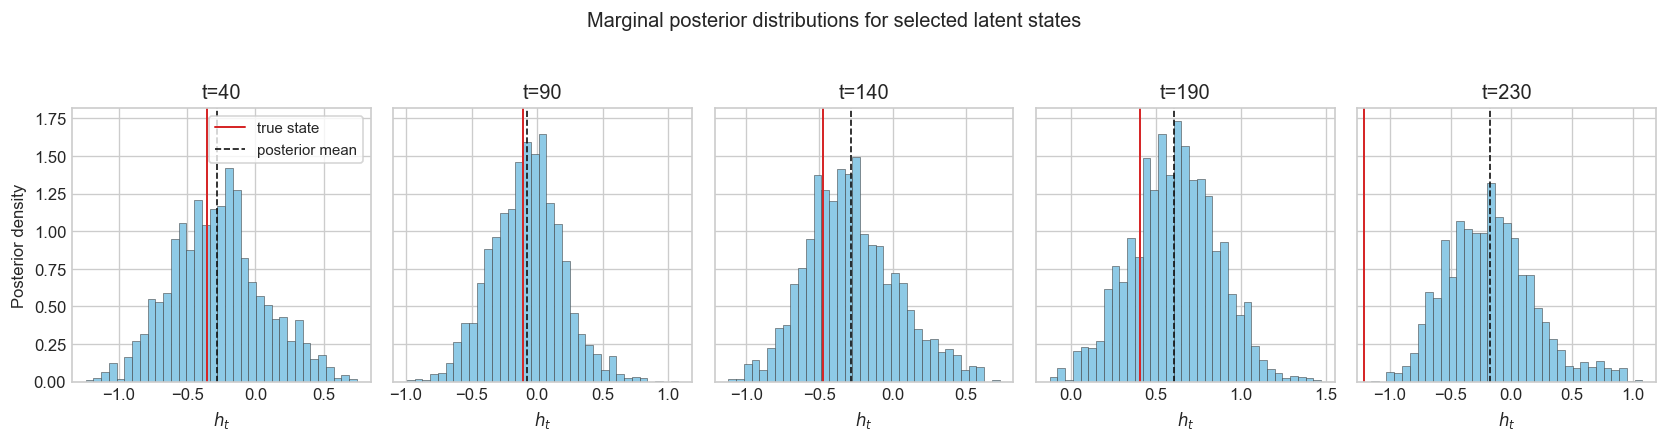

In [8]:
fig, axes = plt.subplots(1, len(selected_idx), figsize=(14, 3.5), sharey=True)
for ax, idx, label in zip(axes, selected_idx, selected_labels):
    ax.hist(posterior_draws[:, idx], bins=35, color="#8ecae6", edgecolor="#333333", linewidth=0.3, density=True)
    ax.axvline(true_h[idx], color="#d62728", linewidth=1.2, label="true state")
    ax.axvline(posterior_mean_h[idx], color="#111111", linestyle="--", linewidth=1.0, label="posterior mean")
    ax.set_title(label)
    ax.set_xlabel(r"$h_t$")
axes[0].set_ylabel("Posterior density")
axes[0].legend(frameon=True)
fig.suptitle("Marginal posterior distributions for selected latent states", y=1.04)
fig.tight_layout()
save_figure(fig, "mcmc_posterior_state_distributions.png")
plt.show()

## 6. Posterior predictive check

A Bayesian model can also be checked by simulating replicated returns from posterior draws of the latent volatility path. The interval below describes the predictive distribution of $|r_t^{rep}|$ conditional on the sampled $h_t$ paths and the assumed Gaussian return shock.

saved: figures/mcmc_simulation/mcmc_posterior_predictive_abs_returns.png


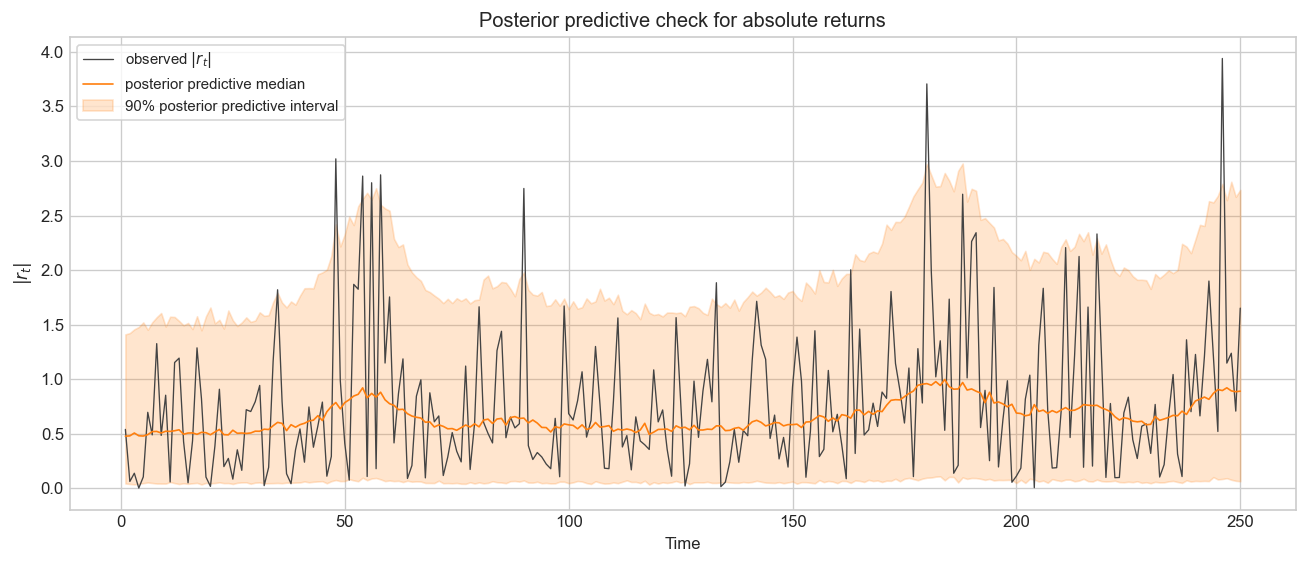

Observed |r_t| inside pointwise 90% posterior predictive interval: 0.916


In [9]:
rng = np.random.default_rng(777)
n_predictive = min(1200, posterior_draws.shape[0])
predictive_idx = rng.choice(posterior_draws.shape[0], size=n_predictive, replace=False)
h_pred = posterior_draws[predictive_idx]
r_rep = np.exp(h_pred / 2) * rng.normal(0, 1, size=h_pred.shape)
abs_rep = np.abs(r_rep)

pred_q05, pred_q50, pred_q95 = np.quantile(abs_rep, [0.05, 0.50, 0.95], axis=0)

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(time_index, np.abs(r), color="#444444", linewidth=0.8, label="observed $|r_t|$")
ax.plot(time_index, pred_q50, color="#ff7f0e", linewidth=1.0, label="posterior predictive median")
ax.fill_between(time_index, pred_q05, pred_q95, color="#ff7f0e", alpha=0.20, label="90% posterior predictive interval")
ax.set_title("Posterior predictive check for absolute returns")
ax.set_xlabel("Time")
ax.set_ylabel(r"$|r_t|$")
ax.legend(frameon=True)
fig.tight_layout()
save_figure(fig, "mcmc_posterior_predictive_abs_returns.png")
plt.show()

predictive_coverage = np.mean((np.abs(r) >= pred_q05) & (np.abs(r) <= pred_q95))
print(f"Observed |r_t| inside pointwise 90% posterior predictive interval: {predictive_coverage:.3f}")

## 7. Figure list

All MCMC figures are saved in a different folder from the SV simulation notebook: `figures/mcmc_simulation/`.

In [10]:
print(f"Figures saved under: {FIGURE_DIR.resolve()}")
for path in sorted(FIGURE_DIR.glob("*.png")):
    print(f"- {path.name}")

Figures saved under: /Users/alexisgod/Desktop/thesis-code/src/figures/mcmc_simulation
- mcmc_acf_selected_states.png
- mcmc_logposterior_acceptance.png
- mcmc_posterior_conditional_sd.png
- mcmc_posterior_log_volatility.png
- mcmc_posterior_predictive_abs_returns.png
- mcmc_posterior_state_distributions.png
- mcmc_simulated_data.png
- mcmc_trace_selected_states.png
